# EEG–POLY connectivity analysis with MNE


1. Проверить метод на Kaggle-датасете: гомологичные EEG-пары должны быть когерентнее дальних контрольных пар.
2. Для собственного проекта посчитать связность между головными EEG-каналами и биполярными шейными POLY/EMG-отведениями.
3. Учитывать, что каждый CSV-файл проекта — это 30-секундная запись одного экспериментального события: например, глаза закрыты, глаза открыты, поднята рука.
4. Считать результаты отдельно по событиям.



## Установка зависимостей


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import mne
import numpy as np
import pandas as pd
from IPython.display import display
from mne_connectivity import spectral_connectivity_epochs

mne.set_log_level("WARNING")

## Настройки

Для проекта используются CSV-файлы формата:

- разделитель `;`;
- кодировка `cp1251`;
- EEG-каналы: `Fp1`, `Fp2`, `O1`, `O2`;
- POLY-каналы: `POLY3`, `POLY4`;
- текст события может быть записан в последней безымянной колонке, например `13:05:09 Глаза закрыты`;
- числовой столбец `event` может быть маркером, но не названием события.

In [2]:
KAGGLE_DIR = Path("kaggle")
KAGGLE_GLOB = "s*.csv"
KAGGLE_FS = 128.0
KAGGLE_ENCODING = "utf-8"
KAGGLE_SEP = None

PROJECT_DIR = Path("data")
PROJECT_GLOB = "*.csv"
PROJECT_FS = 500.0
PROJECT_ENCODING = "cp1251"
PROJECT_SEP = ";"

# Один файл проекта длится примерно 30 секунд.
# 3 секунды дают 10 эпох на файл без остатка.
EPOCH_SEC = 3.0

FILTER_RANGE = (1.0, 45.0)
COHERENCE_LIMIT = 0.50
MAX_SECONDS = None

# Простая автоматическая отбраковка плохих эпох.
# Чем больше значение, тем мягче фильтр.
EPOCH_REJECT_Z = 8.0


PROJECT_IGNORE_CHANNELS = {"A1", "A2", "VIDEO", "AUDIO", "EVENT", "MARKER", "TRIGGER"}

BANDS = {
    "delta": (1.0, 4.0),
    "theta": (4.0, 8.0),
    "alpha": (8.0, 13.0),
    "beta": (13.0, 30.0),
    "high_beta": (20.0, 30.0),
    "low_gamma": (30.0, 45.0),
}

METHODS = ["coh", "imcoh", "plv", "pli", "wpli"]

## Каналы Kaggle и проверочные пары

Kaggle используется как контроль: ожидается, что гомологичные пары будут иметь более высокую когерентность, чем дальние контрольные пары.

In [3]:
KAGGLE_CHANNELS_19 = [
    "Fp1", "Fp2", "F7", "F3", "Fz", "F4", "F8",
    "T7", "C3", "Cz", "C4", "T8",
    "P7", "P3", "Pz", "P4", "P8", "O1", "O2",
]

kaggle_pairs_df = pd.DataFrame([
    {"ch1": "Fp1", "ch2": "Fp2", "expected": "homologous"},
    {"ch1": "F3",  "ch2": "F4",  "expected": "homologous"},
    {"ch1": "C3",  "ch2": "C4",  "expected": "homologous"},
    {"ch1": "P3",  "ch2": "P4",  "expected": "homologous"},
    {"ch1": "O1",  "ch2": "O2",  "expected": "homologous_occipital"},
    {"ch1": "Fp1", "ch2": "O2",  "expected": "distant_control"},
    {"ch1": "Fp2", "ch2": "O1",  "expected": "distant_control"},
    {"ch1": "F3",  "ch2": "O2",  "expected": "distant_control"},
])

## Загрузка CSV с сохранением события

В проектных CSV текст события может быть не в колонке `event`, а в последней безымянной колонке. Поэтому событие ищется среди текстовых значений всех нечисловых колонок. Если текст события содержит время, например `13:05:09 Глаза закрыты`, время удаляется и остаётся только название события.

In [4]:
def clean_event_text(value):
    if pd.isna(value):
        return None
    text = str(value).strip()
    if not text:
        return None
    parts = text.split(maxsplit=1)
    if len(parts) == 2 and parts[0].count(":") >= 1:
        return parts[1].strip()
    return text


def extract_event_label(raw, path):
    # 1) Ищем текстовое событие в object-колонках.
    text_values = []
    for col in raw.columns:
        if raw[col].dtype == "object":
            values = raw[col].dropna().map(clean_event_text)
            values = values[values.notna()]
            values = values[values.astype(str).str.len() > 0]
            text_values.extend(values.tolist())

    if text_values:
        return text_values[0]

    # 2) Если текстового события нет, используем имя файла, это нкужно для проверки на данных с kaggle. 
    return Path(path).stem


def read_csv_with_event(path, fs, dataset, channel_names=None, encoding="utf-8", sep=None):
    if channel_names is None:
        raw = pd.read_csv(path, encoding=encoding, sep=sep, engine="python", index_col=False)
    else:
        raw = pd.read_csv(path, header=None, encoding=encoding, sep=sep, engine="python", index_col=False)
        raw.columns = channel_names[:raw.shape[1]]

    raw = raw.loc[:, ~raw.columns.astype(str).str.startswith("Unnamed") | raw.notna().any(axis=0)]
    event_label = extract_event_label(raw, path)

    # Технические и текстовые колонки не превращаем в сигналы.
    non_signal = {"dataset", "file", "sample", "time", "event", "event_label"}
    numeric = pd.DataFrame(index=raw.index)

    for col in raw.columns:
        col_name = str(col)
        converted = pd.to_numeric(
            raw[col].astype(str).str.replace(",", ".", regex=False),
            errors="coerce",
        )
        if col_name.lower().startswith("unnamed"):
            continue
        if converted.notna().sum() == 0:
            continue
        numeric[col_name] = converted

    numeric = numeric.dropna(axis=1, how="all")
    numeric = numeric.interpolate(limit_direction="both")

    data = numeric.copy()
    data.insert(0, "time", np.arange(len(data)) / fs)
    data.insert(0, "sample", np.arange(len(data)))
    data.insert(0, "event_label", event_label)
    data.insert(0, "file", Path(path).name)
    data.insert(0, "dataset", dataset)
    return data


def load_csv_folder(folder, pattern, fs, dataset, channel_names=None, encoding="utf-8", sep=None):
    files = sorted(Path(folder).glob(pattern))
    dataframes = [
        read_csv_with_event(path, fs, dataset, channel_names, encoding, sep)
        for path in files
    ]
    if not dataframes:
        raise FileNotFoundError(f"No files found: {Path(folder) / pattern}")
    return pd.concat(dataframes, ignore_index=True)


def signal_columns(data_df):
    meta = {"dataset", "file", "event_label", "sample", "time"}
    return [col for col in data_df.columns if col not in meta]


def show_channels(data_df):
    return ", ".join(signal_columns(data_df))

## Предобработка и перевод DataFrame в MNE Epochs

Выполняется базовая предобработка:

1. числовые каналы берутся из `DataFrame`;
2. для каждого файла отдельно убирается DC-смещение;
3. создаётся MNE `RawArray`;
4. выполняется полосовая фильтрация `1–45 Hz`;
5. запись режется на 3-секундные эпохи;
6. для каждой эпохи сохраняется `metadata`: файл и событие;
7. явно плохие эпохи отбрасываются по робастному амплитудному критерию.

EEG записаны относительно Av. POLY-каналы рассматриваются как EMG.

In [5]:
def channel_type(name):
    if str(name).upper().startswith("POLY"):
        return "emg"
    return "eeg"


def robust_epoch_mask(epoch_data, z_limit=EPOCH_REJECT_Z):
    # epoch_data shape: n_epochs × n_channels × n_times
    if len(epoch_data) == 0:
        return np.array([], dtype=bool)

    finite_mask = np.isfinite(epoch_data).all(axis=(1, 2))
    ptp = np.ptp(epoch_data, axis=2)

    med = np.nanmedian(ptp, axis=0)
    mad = np.nanmedian(np.abs(ptp - med), axis=0)
    scale = 1.4826 * mad
    scale[scale == 0] = np.nan

    z = np.abs((ptp - med) / scale)
    robust_mask = np.nanmax(z, axis=1) < z_limit

    # Убираем почти постоянные эпохи.
    std_mask = np.nanmin(np.std(epoch_data, axis=2), axis=1) > 0
    return finite_mask & robust_mask & std_mask


def dataframe_to_epochs(
    data_df,
    channels,
    fs,
    epoch_sec=EPOCH_SEC,
    filter_range=FILTER_RANGE,
    max_seconds=MAX_SECONDS,
    reject_bad=True,
):
    arrays = []
    metadata_rows = []

    info = mne.create_info(
        ch_names=list(channels),
        sfreq=fs,
        ch_types=[channel_type(ch) for ch in channels],
    )

    for file_name, file_df in data_df.groupby("file", sort=False):
        file_df = file_df.copy()
        if max_seconds is not None:
            file_df = file_df.iloc[: int(max_seconds * fs)]

        event_label = str(file_df["event_label"].iloc[0]) if "event_label" in file_df else "unknown"
        values = file_df[list(channels)].to_numpy(dtype=float).T

        # Удаление постоянного смещения отдельно для каждого файла и каждого канала.
        values = values - np.nanmean(values, axis=1, keepdims=True)

        raw = mne.io.RawArray(values, info.copy(), verbose=False)
        raw.filter(filter_range[0], filter_range[1], method="iir", verbose=False)

        epochs = mne.make_fixed_length_epochs(
            raw,
            duration=epoch_sec,
            overlap=0.0,
            preload=True,
            verbose=False,
        )

        epoch_data = epochs.get_data()
        if reject_bad:
            mask = robust_epoch_mask(epoch_data)
            epoch_data = epoch_data[mask]
        else:
            mask = np.ones(len(epoch_data), dtype=bool)

        arrays.append(epoch_data)
        kept_indices = np.where(mask)[0]
        for epoch_i in kept_indices:
            metadata_rows.append({
                "file": file_name,
                "event_label": event_label,
                "epoch_in_file": int(epoch_i),
            })

    data = np.concatenate(arrays, axis=0)
    metadata = pd.DataFrame(metadata_rows)
    return mne.EpochsArray(data, info, metadata=metadata, verbose=False)

## Расчёт connectivity



In [6]:
def connectivity_for_pairs(epochs, pairs_df, bands=BANDS, methods=METHODS, event_label="all"):
    ch_names = epochs.ch_names
    pairs_df = pairs_df.reset_index(drop=True)

    left = [ch_names.index(ch) for ch in pairs_df["ch1"]]
    right = [ch_names.index(ch) for ch in pairs_df["ch2"]]

    conns = spectral_connectivity_epochs(
        epochs,
        method=methods,
        indices=(left, right),
        sfreq=epochs.info["sfreq"],
        mode="fourier",
        fmin=[v[0] for v in bands.values()],
        fmax=[v[1] for v in bands.values()],
        faverage=True,
        verbose=False,
    )

    if not isinstance(conns, (list, tuple)):
        conns = [conns]

    data_by_method = {}
    for method, conn in zip(methods, conns):
        values = np.asarray(conn.get_data())
        if values.ndim == 1:
            values = values[:, None]
        if values.ndim == 3:
            values = np.array([values[l, r, :] for l, r in zip(left, right)])
        data_by_method[method] = values

    rows = []
    for pair_i, pair in pairs_df.iterrows():
        for band_i, (band_name, band_range) in enumerate(bands.items()):
            row = pair.to_dict()
            row["event_label"] = event_label
            row["pair"] = f"{pair['ch1']}-{pair['ch2']}"
            row["band"] = band_name
            row["fmin"] = band_range[0]
            row["fmax"] = band_range[1]
            for method in methods:
                row[method] = float(data_by_method[method][pair_i, band_i])
            rows.append(row)

    return pd.DataFrame(rows)


def run_mne_analysis(data_df, pairs_df, fs, by_event=False):
    channels = sorted(set(pairs_df["ch1"]).union(set(pairs_df["ch2"])))
    epochs = dataframe_to_epochs(data_df, channels, fs)

    if not by_event:
        results_df = connectivity_for_pairs(epochs, pairs_df, event_label="all")
        return epochs, results_df

    result_parts = []
    for event in sorted(epochs.metadata["event_label"].dropna().unique()):
        mask = epochs.metadata["event_label"].values == event
        event_epochs = epochs[mask]
        if len(event_epochs) < 2:
            continue
        result_parts.append(connectivity_for_pairs(event_epochs, pairs_df, event_label=event))

    results_df = pd.concat(result_parts, ignore_index=True)
    return epochs, results_df

## Графики

In [7]:
def plot_band_bars(results_df, band, metric, title):
    values = results_df[results_df["band"] == band].copy()
    if "event_label" in values.columns and values["event_label"].nunique() > 1:
        values = values.groupby(["event_label", "pair"], as_index=False)[metric].mean()
        labels = values["event_label"] + " | " + values["pair"]
    else:
        labels = values["pair"]

    values = values.sort_values(metric, ascending=False)
    labels = labels.loc[values.index]

    plt.figure(figsize=(12, 4))
    plt.bar(labels, values[metric])
    plt.axhline(COHERENCE_LIMIT, linestyle="--")
    plt.title(title)
    plt.ylabel(metric)
    plt.xticks(rotation=75, ha="right")
    plt.tight_layout()
    plt.show()


def plot_band_heatmap(results_df, metric, title):
    pivot = results_df.pivot_table(index="pair", columns="band", values=metric, aggfunc="mean")
    pivot = pivot[list(BANDS.keys())]

    plt.figure(figsize=(10, max(4, 0.35 * len(pivot))))
    plt.imshow(pivot.values, aspect="auto")
    plt.colorbar(label=metric)
    plt.title(title)
    plt.xticks(range(len(pivot.columns)), pivot.columns, rotation=45, ha="right")
    plt.yticks(range(len(pivot.index)), pivot.index)
    plt.tight_layout()
    plt.show()


def plot_event_band_heatmap(results_df, pair, metric="coh", title=None):
    values = results_df[results_df["pair"] == pair]
    pivot = values.pivot_table(index="event_label", columns="band", values=metric, aggfunc="mean")
    pivot = pivot[list(BANDS.keys())]

    plt.figure(figsize=(10, max(3, 0.5 * len(pivot))))
    plt.imshow(pivot.values, aspect="auto")
    plt.colorbar(label=metric)
    plt.title(title or f"{pair}: {metric} by event and band")
    plt.xticks(range(len(pivot.columns)), pivot.columns, rotation=45, ha="right")
    plt.yticks(range(len(pivot.index)), pivot.index)
    plt.tight_layout()
    plt.show()


def plot_poly_matrix(results_df, event_label, band, metric, title):
    values = results_df[
        (results_df["event_label"] == event_label) &
        (results_df["band"] == band)
    ].copy()

    values["eeg"] = values["ch1"]
    values["poly"] = values["ch2"]
    pivot = values.pivot_table(index="eeg", columns="poly", values=metric, aggfunc="mean")

    plt.figure(figsize=(6, max(3, 0.4 * len(pivot))))
    plt.imshow(pivot.values, aspect="auto")
    plt.colorbar(label=metric)
    plt.title(title)
    plt.xticks(range(len(pivot.columns)), pivot.columns)
    plt.yticks(range(len(pivot.index)), pivot.index)
    plt.tight_layout()
    plt.show()


def plot_event_summary(results_df, band="beta", metric="coh"):
    values = results_df[results_df["band"] == band]
    summary = values.groupby("event_label", as_index=False)[metric].mean().sort_values(metric, ascending=False)

    plt.figure(figsize=(8, 4))
    plt.bar(summary["event_label"], summary[metric])
    plt.axhline(COHERENCE_LIMIT, linestyle="--")
    plt.title(f"Mean EEG-POLY {metric} by event, {band}")
    plt.ylabel(metric)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


def plot_pair_spectra(epochs, pairs_df, title, metric="coh", fmin=1, fmax=45):
    ch_names = epochs.ch_names
    pairs_df = pairs_df.reset_index(drop=True)
    left = [ch_names.index(ch) for ch in pairs_df["ch1"]]
    right = [ch_names.index(ch) for ch in pairs_df["ch2"]]

    conn = spectral_connectivity_epochs(
        epochs,
        method=metric,
        indices=(left, right),
        sfreq=epochs.info["sfreq"],
        mode="fourier",
        fmin=fmin,
        fmax=fmax,
        faverage=False,
        verbose=False,
    )

    values = np.asarray(conn.get_data())
    if values.ndim == 3:
        values = np.array([values[l, r, :] for l, r in zip(left, right)])
    freqs = np.asarray(conn.freqs)

    plt.figure(figsize=(10, 5))
    for i, pair in pairs_df.iterrows():
        plt.plot(freqs, values[i], label=f"{pair['ch1']}-{pair['ch2']}")

    plt.axhline(COHERENCE_LIMIT, linestyle="--")
    for name, (lo, hi) in BANDS.items():
        plt.axvspan(lo, hi, alpha=0.08)
    plt.title(title)
    plt.xlabel("Frequency, Hz")
    plt.ylabel(metric)
    plt.legend(loc="upper right", fontsize=8)
    plt.tight_layout()
    plt.show()


def plot_connectivity_by_band(results_df, metric="coh", group_col=None, title=None):
    """Plot mean connectivity values by frequency band.

    If group_col is provided, the plot compares groups within each band,
    for example expected pair type on Kaggle or event_label in the project data.
    """
    values = results_df.copy()
    band_order = [band for band in BANDS.keys() if band in set(values["band"])]
    if not band_order:
        raise ValueError("No known frequency bands found in results_df['band'].")

    plt.figure(figsize=(10, 4))

    if group_col is not None and group_col in values.columns and values[group_col].nunique() > 1:
        summary = values.groupby(["band", group_col], as_index=False)[metric].mean()
        pivot = summary.pivot(index="band", columns=group_col, values=metric).reindex(band_order)
        groups = list(pivot.columns)
        x = np.arange(len(pivot.index))
        width = min(0.8 / max(len(groups), 1), 0.35)

        for i, group in enumerate(groups):
            offset = (i - (len(groups) - 1) / 2) * width
            plt.bar(x + offset, pivot[group].values, width=width, label=str(group))

        plt.xticks(x, pivot.index, rotation=45, ha="right")
        plt.legend(title=group_col)
    else:
        summary = values.groupby("band", as_index=False)[metric].mean()
        summary = summary.set_index("band").reindex(band_order).reset_index()
        plt.bar(summary["band"], summary[metric])
        plt.xticks(rotation=45, ha="right")

    if metric == "coh":
        plt.axhline(COHERENCE_LIMIT, linestyle="--")
    plt.title(title or f"Mean {metric} by frequency band")
    plt.xlabel("Frequency band")
    plt.ylabel(metric)
    plt.tight_layout()
    plt.show()


def plot_connectivity_by_event(results_df, metric="coh", band=None, title=None):
    """Plot mean connectivity values by experimental event.

    If band is not specified, all available frequency bands are shown for each event.
    """
    if "event_label" not in results_df.columns or results_df["event_label"].nunique() <= 1:
        print("The results table does not contain multiple event labels.")
        return

    values = results_df.copy()
    if band is not None:
        values = values[values["band"] == band].copy()
        summary = values.groupby("event_label", as_index=False)[metric].mean().sort_values("event_label")

        plt.figure(figsize=(8, 4))
        plt.bar(summary["event_label"], summary[metric])
        if metric == "coh":
            plt.axhline(COHERENCE_LIMIT, linestyle="--")
        plt.title(title or f"Mean {metric} by event, {band}")
        plt.xlabel("Event")
        plt.ylabel(metric)
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()
        return

    band_order = [band_name for band_name in BANDS.keys() if band_name in set(values["band"])]
    summary = values.groupby(["event_label", "band"], as_index=False)[metric].mean()
    pivot = summary.pivot(index="event_label", columns="band", values=metric)
    pivot = pivot[[band_name for band_name in band_order if band_name in pivot.columns]]

    x = np.arange(len(pivot.index))
    bands = list(pivot.columns)
    width = min(0.8 / max(len(bands), 1), 0.18)

    plt.figure(figsize=(11, 4))
    for i, band_name in enumerate(bands):
        offset = (i - (len(bands) - 1) / 2) * width
        plt.bar(x + offset, pivot[band_name].values, width=width, label=band_name)

    if metric == "coh":
        plt.axhline(COHERENCE_LIMIT, linestyle="--")
    plt.title(title or f"Mean {metric} by event and frequency band")
    plt.xlabel("Event")
    plt.ylabel(metric)
    plt.xticks(x, pivot.index, rotation=45, ha="right")
    plt.legend(title="Band")
    plt.tight_layout()
    plt.show()


# 1. Проверка на Kaggle

In [8]:
kaggle_df = load_csv_folder(
    folder=KAGGLE_DIR,
    pattern=KAGGLE_GLOB,
    fs=KAGGLE_FS,
    dataset="kaggle",
    channel_names=KAGGLE_CHANNELS_19,
    encoding=KAGGLE_ENCODING,
    sep=KAGGLE_SEP,
)

print("Kaggle shape:", kaggle_df.shape)
print("Kaggle channels:", show_channels(kaggle_df))

Kaggle shape: (155000, 24)
Kaggle channels: Fp1, Fp2, F7, F3, Fz, F4, F8, T7, C3, Cz, C4, T8, P7, P3, Pz, P4, P8, O1, O2


In [9]:
kaggle_epochs, kaggle_results_df = run_mne_analysis(
    kaggle_df,
    kaggle_pairs_df,
    KAGGLE_FS,
    by_event=False,
)

print("Kaggle epochs:", len(kaggle_epochs))
display(kaggle_results_df.round(3))

Kaggle epochs: 394


C:\Users\chuma\AppData\Local\Temp\ipykernel_11864\3176381985.py:8: RuntimeWarning: fmin=1.000 Hz corresponds to 3.000 < 5 cycles based on the epoch length 3.000 sec, need at least 5.000 sec epochs or fmin=1.667. Spectrum estimate will be unreliable.
  conns = spectral_connectivity_epochs(


,ch1,ch2,expected,event_label,pair,band,fmin,fmax,coh,imcoh,plv,pli,wpli
0,Fp1,Fp2,homologous,all,Fp1-Fp2,delta,1.0,4.0,0.652,-0.005,0.531,0.048,0.076
1,Fp1,Fp2,homologous,all,Fp1-Fp2,theta,4.0,8.0,0.531,0.017,0.440,0.043,0.049
2,Fp1,Fp2,homologous,all,Fp1-Fp2,alpha,8.0,13.0,0.446,-0.004,0.353,0.040,0.113
3,Fp1,Fp2,homologous,all,Fp1-Fp2,beta,13.0,30.0,0.601,-0.016,0.251,0.055,0.261
4,Fp1,Fp2,homologous,all,Fp1-Fp2,high_beta,20.0,30.0,0.730,0.005,0.207,0.053,0.319
5,Fp1,Fp2,homologous,all,Fp1-Fp2,low_gamma,30.0,45.0,0.789,0.002,0.187,0.044,0.518
6,F3,F4,homologous,all,F3-F4,delta,1.0,4.0,0.797,0.008,0.663,0.047,0.074
7,F3,F4,homologous,all,F3-F4,theta,4.0,8.0,0.721,-0.022,0.595,0.051,0.100
8,F3,F4,homologous,all,F3-F4,alpha,8.0,13.0,0.587,-0.031,0.451,0.063,0.106
9,F3,F4,homologous,all,F3-F4,beta,13.0,30.0,0.639,-0.018,0.362,0.047,0.272


In [10]:
kaggle_alpha_df = kaggle_results_df[kaggle_results_df["band"] == "alpha"].copy()
display(kaggle_alpha_df.sort_values("coh", ascending=False).round(3))

kaggle_group_summary = (
    kaggle_alpha_df
    .groupby("expected", as_index=False)[["coh", "imcoh", "plv", "pli", "wpli"]]
    .mean()
    .sort_values("coh", ascending=False)
)
display(kaggle_group_summary.round(3))

,ch1,ch2,expected,event_label,pair,band,fmin,fmax,coh,imcoh,plv,pli,wpli
20,P3,P4,homologous,all,P3-P4,alpha,8.0,13.0,0.754,-0.004,0.664,0.038,0.074
26,O1,O2,homologous_occipital,all,O1-O2,alpha,8.0,13.0,0.667,-0.011,0.570,0.039,0.077
8,F3,F4,homologous,all,F3-F4,alpha,8.0,13.0,0.587,-0.031,0.451,0.063,0.106
14,C3,C4,homologous,all,C3-C4,alpha,8.0,13.0,0.582,0.031,0.511,0.042,0.119
2,Fp1,Fp2,homologous,all,Fp1-Fp2,alpha,8.0,13.0,0.446,-0.004,0.353,0.040,0.113
44,F3,O2,distant_control,all,F3-O2,alpha,8.0,13.0,0.420,0.001,0.351,0.053,0.073
38,Fp2,O1,distant_control,all,Fp2-O1,alpha,8.0,13.0,0.352,-0.016,0.321,0.034,0.077
32,Fp1,O2,distant_control,all,Fp1-O2,alpha,8.0,13.0,0.188,0.014,0.148,0.038,0.075


,expected,coh,imcoh,plv,pli,wpli
2,homologous_occipital,0.667,-0.011,0.570,0.039,0.077
1,homologous,0.592,-0.002,0.495,0.046,0.103
0,distant_control,0.320,-0.001,0.273,0.042,0.075


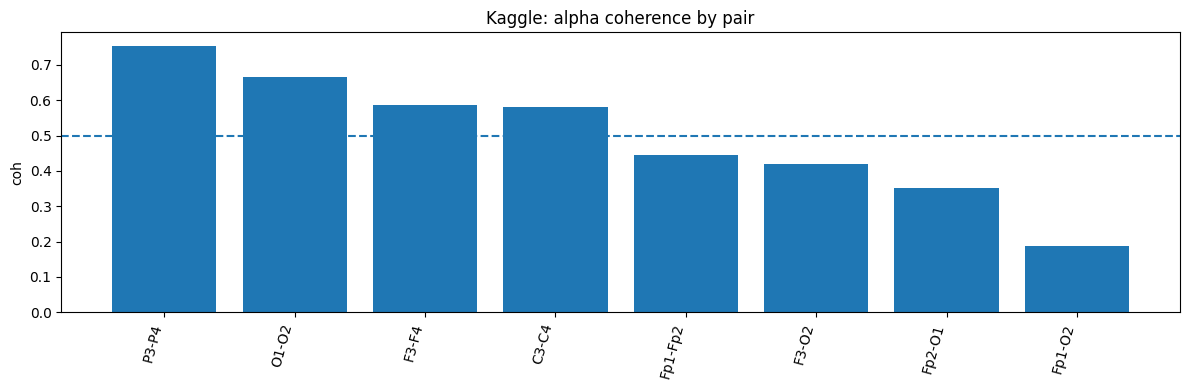

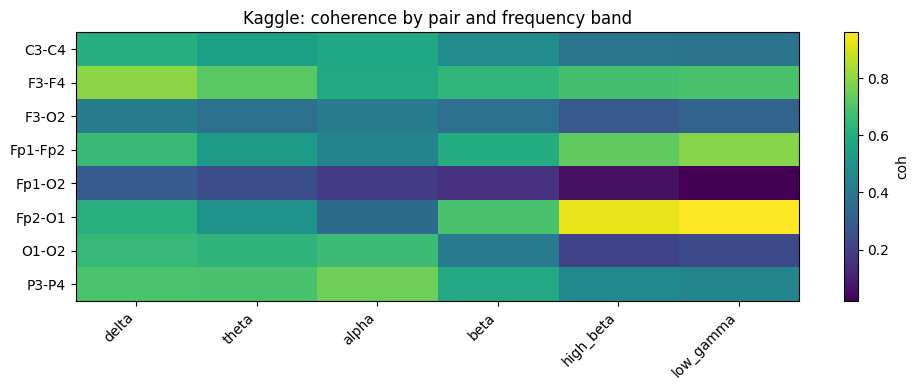

C:\Users\chuma\AppData\Local\Temp\ipykernel_11864\3864869725.py:91: RuntimeWarning: fmin=1.000 Hz corresponds to 3.000 < 5 cycles based on the epoch length 3.000 sec, need at least 5.000 sec epochs or fmin=1.667. Spectrum estimate will be unreliable.
  conn = spectral_connectivity_epochs(


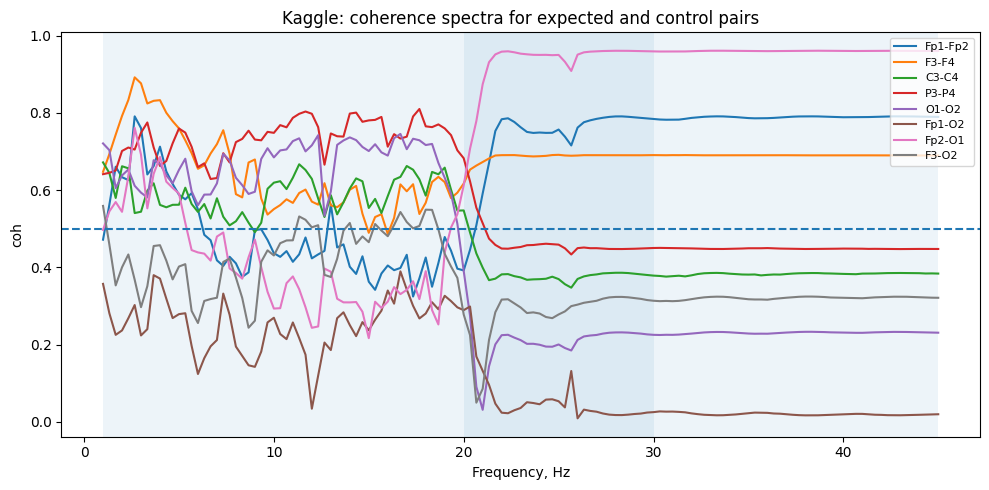

In [11]:
plot_band_bars(
    kaggle_results_df,
    band="alpha",
    metric="coh",
    title="Kaggle: alpha coherence by pair",
)

plot_band_heatmap(
    kaggle_results_df,
    metric="coh",
    title="Kaggle: coherence by pair and frequency band",
)

plot_pair_spectra(
    kaggle_epochs,
    kaggle_pairs_df,
    title="Kaggle: coherence spectra for expected and control pairs",
    metric="coh",
)

## Дополнительное сравнение Kaggle по частотным диапазонам

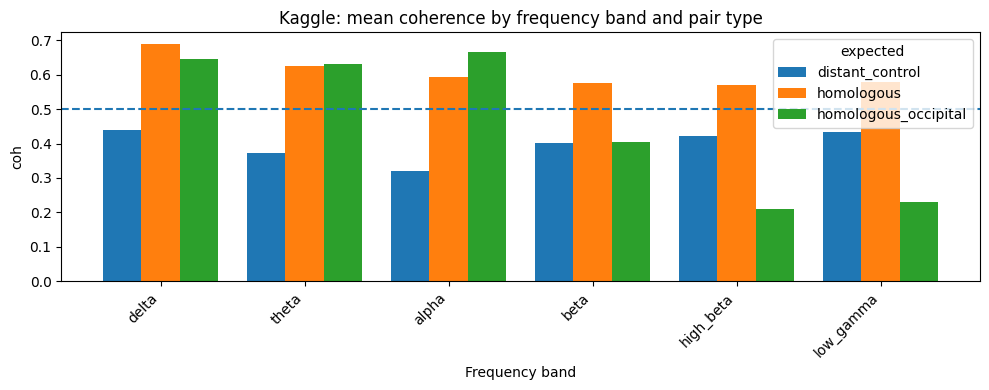

In [12]:
plot_connectivity_by_band(
    kaggle_results_df,
    metric="coh",
    group_col="expected",
    title="Kaggle: mean coherence by frequency band and pair type",
)

# 2. Анализ проекта по событиям

Для проекта пары создаются автоматически: каждый головной EEG-канал сравнивается с каждым POLY/EMG-каналом.

In [13]:
project_df = load_csv_folder(
    folder=PROJECT_DIR,
    pattern=PROJECT_GLOB,
    fs=PROJECT_FS,
    dataset="project",
    channel_names=None,
    encoding=PROJECT_ENCODING,
    sep=PROJECT_SEP,
)

print("Project shape:", project_df.shape)
print("Project channels:", show_channels(project_df))
print("Project events:", sorted(project_df["event_label"].dropna().unique()))
display(project_df.head())

Project shape: (734702, 16)
Project channels: Fp1, Fp2, O1, O2, POLY3, POLY4, A1, A2, Video, Audio, event
Project events: ['Глаза закрыты', 'Глаза открыты', 'Рука']


,dataset,file,event_label,sample,time,Fp1,Fp2,O1,O2,POLY3,POLY4,A1,A2,Video,Audio,event
0,project,251215_000006_EEG_1.csv,Глаза закрыты,0,0.000,24395.45,14759.410,-2816.1720,23544.08,11.16727,-7.947074,19666.200,10352.860,0.304437,-0.270134,0
1,project,251215_000006_EEG_1.csv,Глаза закрыты,1,0.002,20504.37,12246.860,-815.4871,19778.46,10.55284,-11.020180,16428.200,7987.599,-0.085673,0.119941,0
2,project,251215_000006_EEG_1.csv,Глаза закрыты,2,0.004,23241.99,14137.120,1600.4150,22400.97,14.35965,-1.899674,18798.160,9830.611,-0.345456,-0.010114,0
3,project,251215_000006_EEG_1.csv,Глаза закрыты,3,0.006,19357.37,12160.520,2561.2610,18870.57,15.48430,3.460748,15917.430,7501.836,-0.215174,-0.399908,0
4,project,251215_000006_EEG_1.csv,Глаза закрыты,4,0.008,-11548.12,-8045.437,2102.6510,-10650.94,16.67419,6.203449,-9855.696,-6041.632,-0.149991,-0.204604,0


In [14]:
def make_project_poly_pairs(data_df):
    channels = signal_columns(data_df)
    poly_channels = [ch for ch in channels if ch.upper().startswith("POLY")]

    eeg_channels = [
        ch for ch in channels
        if ch not in poly_channels
        and ch.upper() not in PROJECT_IGNORE_CHANNELS
    ]

    return pd.DataFrame([
        {"ch1": eeg, "ch2": poly, "expected": "eeg_neck_emg"}
        for eeg in eeg_channels
        for poly in poly_channels
    ])


project_pairs_df = make_project_poly_pairs(project_df)
display(project_pairs_df)

,ch1,ch2,expected
0,Fp1,POLY3,eeg_neck_emg
1,Fp1,POLY4,eeg_neck_emg
2,Fp2,POLY3,eeg_neck_emg
3,Fp2,POLY4,eeg_neck_emg
4,O1,POLY3,eeg_neck_emg
5,O1,POLY4,eeg_neck_emg
6,O2,POLY3,eeg_neck_emg
7,O2,POLY4,eeg_neck_emg


In [15]:
project_epochs, project_results_df = run_mne_analysis(
    project_df,
    project_pairs_df,
    PROJECT_FS,
    by_event=True,
)

print("Project epochs after preprocessing:", len(project_epochs))
display(project_results_df.round(3))

Project epochs after preprocessing: 201


C:\Users\chuma\AppData\Local\Temp\ipykernel_11864\3176381985.py:8: RuntimeWarning: fmin=1.000 Hz corresponds to 3.000 < 5 cycles based on the epoch length 3.000 sec, need at least 5.000 sec epochs or fmin=1.667. Spectrum estimate will be unreliable.
  conns = spectral_connectivity_epochs(
C:\Users\chuma\AppData\Local\Temp\ipykernel_11864\3176381985.py:8: RuntimeWarning: fmin=1.000 Hz corresponds to 3.000 < 5 cycles based on the epoch length 3.000 sec, need at least 5.000 sec epochs or fmin=1.667. Spectrum estimate will be unreliable.
  conns = spectral_connectivity_epochs(
C:\Users\chuma\AppData\Local\Temp\ipykernel_11864\3176381985.py:8: RuntimeWarning: fmin=1.000 Hz corresponds to 3.000 < 5 cycles based on the epoch length 3.000 sec, need at least 5.000 sec epochs or fmin=1.667. Spectrum estimate will be unreliable.
  conns = spectral_connectivity_epochs(


,ch1,ch2,expected,event_label,pair,band,fmin,fmax,coh,imcoh,plv,pli,wpli
0,Fp1,POLY3,eeg_neck_emg,Глаза закрыты,Fp1-POLY3,delta,1.0,4.0,0.075,0.048,0.110,0.110,0.148
1,Fp1,POLY3,eeg_neck_emg,Глаза закрыты,Fp1-POLY3,theta,4.0,8.0,0.142,0.009,0.124,0.110,0.175
2,Fp1,POLY3,eeg_neck_emg,Глаза закрыты,Fp1-POLY3,alpha,8.0,13.0,0.097,-0.004,0.116,0.082,0.111
3,Fp1,POLY3,eeg_neck_emg,Глаза закрыты,Fp1-POLY3,beta,13.0,30.0,0.114,0.028,0.108,0.094,0.149
4,Fp1,POLY3,eeg_neck_emg,Глаза закрыты,Fp1-POLY3,high_beta,20.0,30.0,0.117,0.012,0.124,0.099,0.153
...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,O2,POLY4,eeg_neck_emg,Рука,O2-POLY4,theta,4.0,8.0,0.108,-0.006,0.146,0.128,0.233
140,O2,POLY4,eeg_neck_emg,Рука,O2-POLY4,alpha,8.0,13.0,0.129,0.017,0.139,0.115,0.205
141,O2,POLY4,eeg_neck_emg,Рука,O2-POLY4,beta,13.0,30.0,0.124,0.002,0.120,0.103,0.140
142,O2,POLY4,eeg_neck_emg,Рука,O2-POLY4,high_beta,20.0,30.0,0.132,0.011,0.117,0.094,0.161


## Сводки по проекту

Сначала смотрим, при каком событии средняя EEG–POLY связность выше. Для шейной EMG особенно информативны `beta`, `high_beta` и `low_gamma`.

In [16]:
for band in ["alpha", "beta", "high_beta", "low_gamma"]:
    summary = (
        project_results_df[project_results_df["band"] == band]
        .groupby("event_label", as_index=False)[["coh", "imcoh", "plv", "pli", "wpli"]]
        .mean()
        .sort_values("coh", ascending=False)
    )
    print(f"\nBand: {band}")
    display(summary.round(3))


Band: alpha


,event_label,coh,imcoh,plv,pli,wpli
2,Рука,0.120,0.002,0.131,0.106,0.193
1,Глаза открыты,0.104,0.010,0.105,0.081,0.167
0,Глаза закрыты,0.101,0.007,0.111,0.085,0.129



Band: beta


,event_label,coh,imcoh,plv,pli,wpli
2,Рука,0.115,-0.000,0.111,0.104,0.153
0,Глаза закрыты,0.110,0.018,0.103,0.095,0.139
1,Глаза открыты,0.108,0.011,0.109,0.103,0.170



Band: high_beta


,event_label,coh,imcoh,plv,pli,wpli
2,Рука,0.119,0.002,0.119,0.111,0.162
0,Глаза закрыты,0.111,0.006,0.109,0.098,0.141
1,Глаза открыты,0.109,0.015,0.108,0.100,0.161



Band: low_gamma


,event_label,coh,imcoh,plv,pli,wpli
2,Рука,0.107,-0.007,0.106,0.097,0.139
0,Глаза закрыты,0.103,0.014,0.107,0.093,0.134
1,Глаза открыты,0.103,0.002,0.101,0.086,0.158


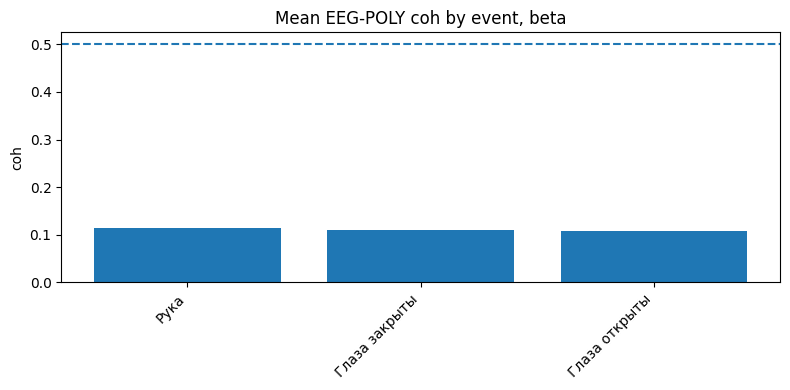

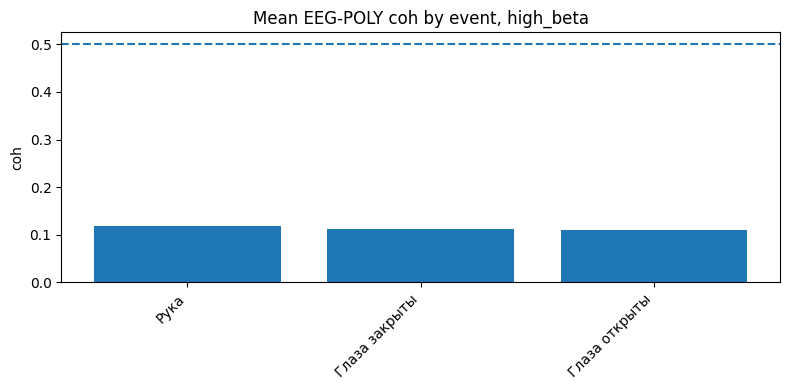

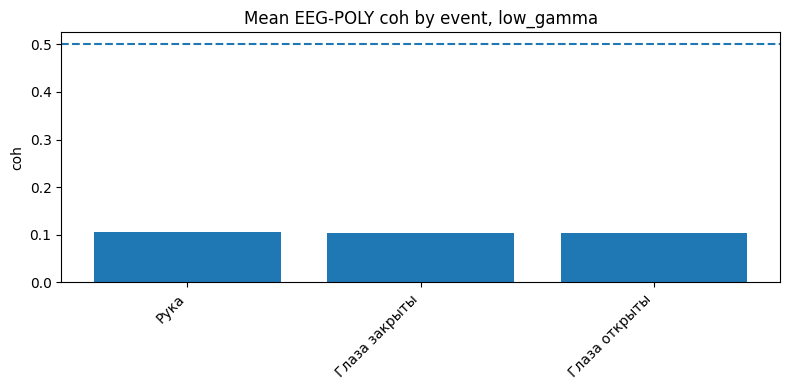

In [17]:
plot_event_summary(project_results_df, band="beta", metric="coh")
plot_event_summary(project_results_df, band="high_beta", metric="coh")
plot_event_summary(project_results_df, band="low_gamma", metric="coh")

## Дополнительное сравнение проекта по диапазонам и событиям

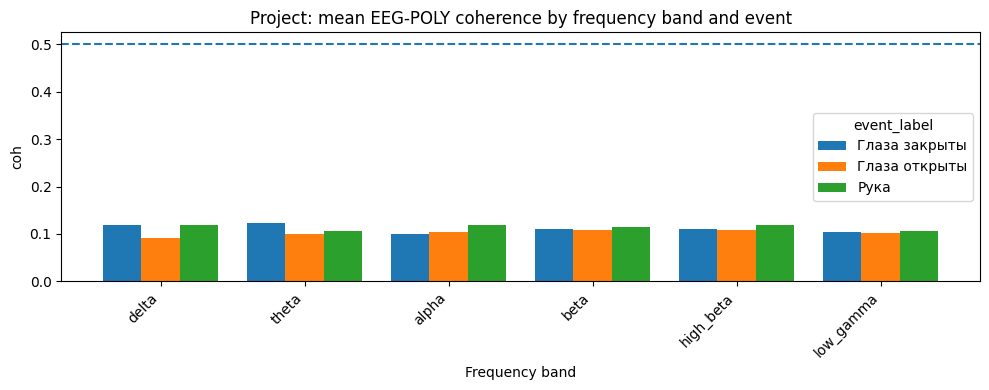

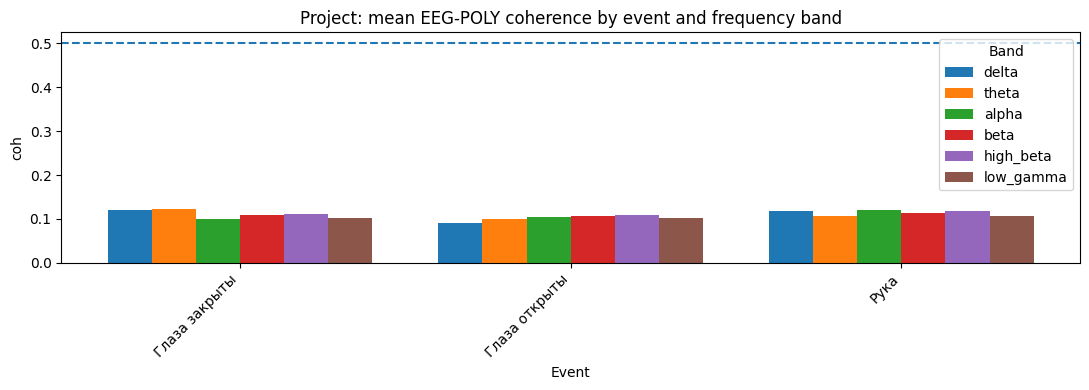

In [18]:
plot_connectivity_by_band(
    project_results_df,
    metric="coh",
    group_col="event_label",
    title="Project: mean EEG-POLY coherence by frequency band and event",
)

plot_connectivity_by_event(
    project_results_df,
    metric="coh",
    title="Project: mean EEG-POLY coherence by event and frequency band",
)

## Графики EEG×POLY по событиям

Для каждого события строятся матрицы `EEG × POLY`. Цвет показывает силу связности.

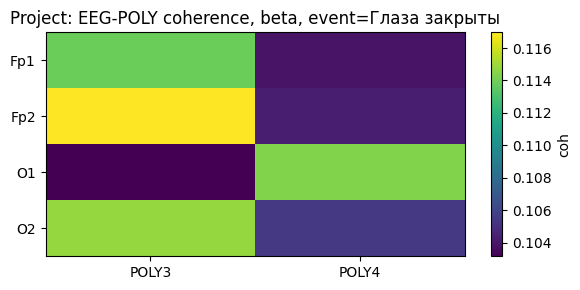

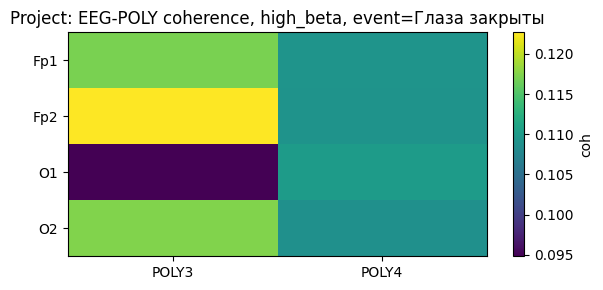

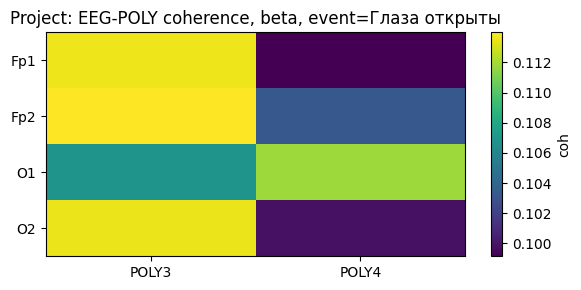

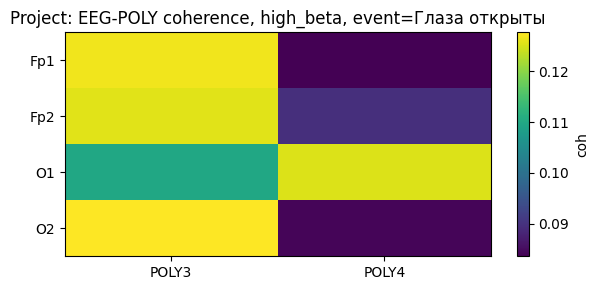

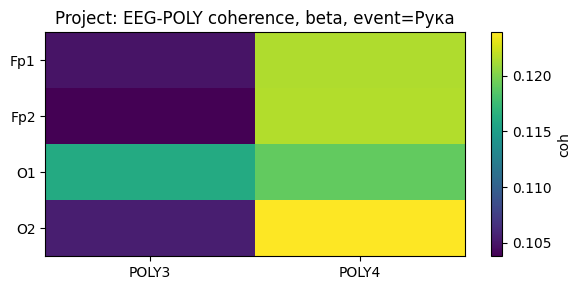

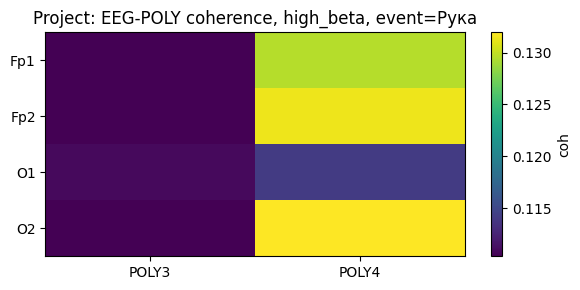

In [19]:
for event in sorted(project_results_df["event_label"].unique()):
    plot_poly_matrix(
        project_results_df,
        event_label=event,
        band="beta",
        metric="coh",
        title=f"Project: EEG-POLY coherence, beta, event={event}",
    )

    plot_poly_matrix(
        project_results_df,
        event_label=event,
        band="high_beta",
        metric="coh",
        title=f"Project: EEG-POLY coherence, high_beta, event={event}",
    )

## Лучшие EEG–POLY пары

In [20]:
top_project = (
    project_results_df[project_results_df["band"].isin(["beta", "high_beta", "low_gamma"])]
    .sort_values("coh", ascending=False)
)

display(top_project.head(20).round(3))

,ch1,ch2,expected,event_label,pair,band,fmin,fmax,coh,imcoh,plv,pli,wpli
142,O2,POLY4,eeg_neck_emg,Рука,O2-POLY4,high_beta,20.0,30.0,0.132,0.011,0.117,0.094,0.161
118,Fp2,POLY4,eeg_neck_emg,Рука,Fp2-POLY4,high_beta,20.0,30.0,0.131,0.010,0.122,0.095,0.166
106,Fp1,POLY4,eeg_neck_emg,Рука,Fp1-POLY4,high_beta,20.0,30.0,0.130,0.009,0.114,0.098,0.163
88,O2,POLY3,eeg_neck_emg,Глаза открыты,O2-POLY3,high_beta,20.0,30.0,0.128,0.032,0.119,0.108,0.191
52,Fp1,POLY3,eeg_neck_emg,Глаза открыты,Fp1-POLY3,high_beta,20.0,30.0,0.127,0.028,0.121,0.101,0.188
64,Fp2,POLY3,eeg_neck_emg,Глаза открыты,Fp2-POLY3,high_beta,20.0,30.0,0.126,0.033,0.116,0.099,0.185
82,O1,POLY4,eeg_neck_emg,Глаза открыты,O1-POLY4,high_beta,20.0,30.0,0.125,-0.002,0.123,0.132,0.197
131,O1,POLY4,eeg_neck_emg,Рука,O1-POLY4,low_gamma,30.0,45.0,0.124,0.012,0.120,0.093,0.133
141,O2,POLY4,eeg_neck_emg,Рука,O2-POLY4,beta,13.0,30.0,0.124,0.002,0.120,0.103,0.140
16,Fp2,POLY3,eeg_neck_emg,Глаза закрыты,Fp2-POLY3,high_beta,20.0,30.0,0.123,0.015,0.122,0.102,0.162


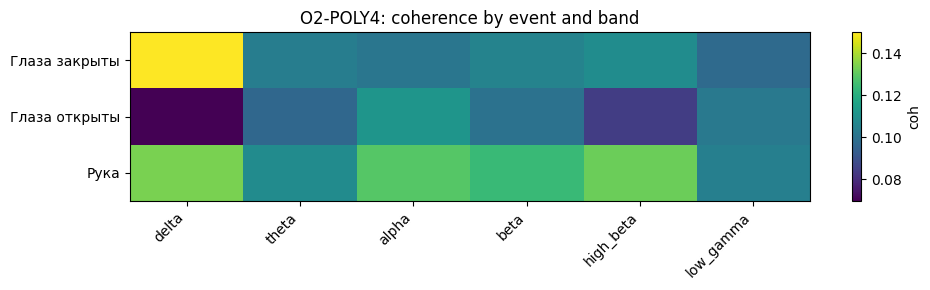

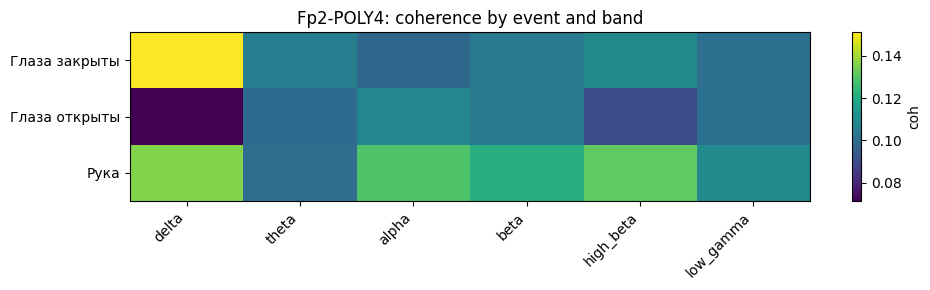

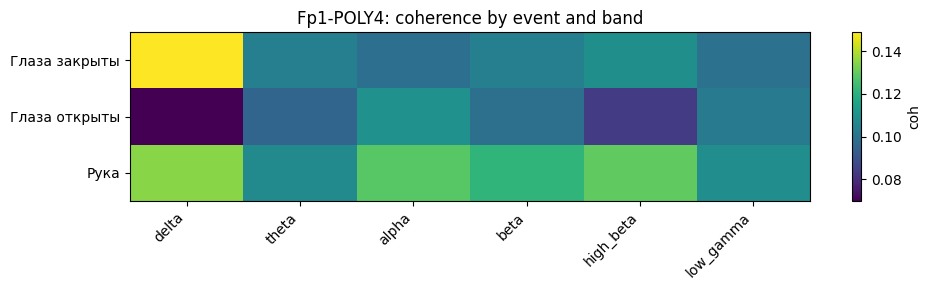

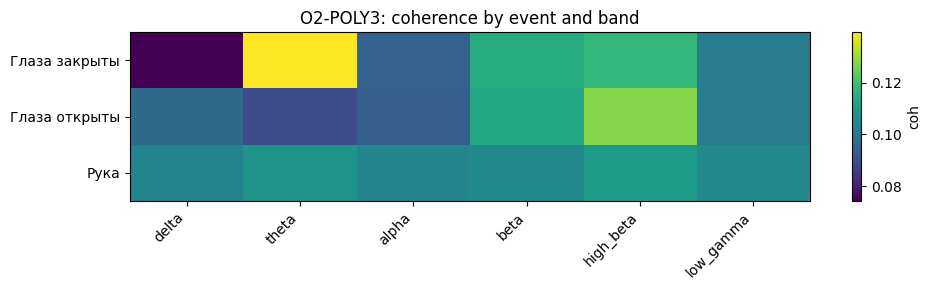

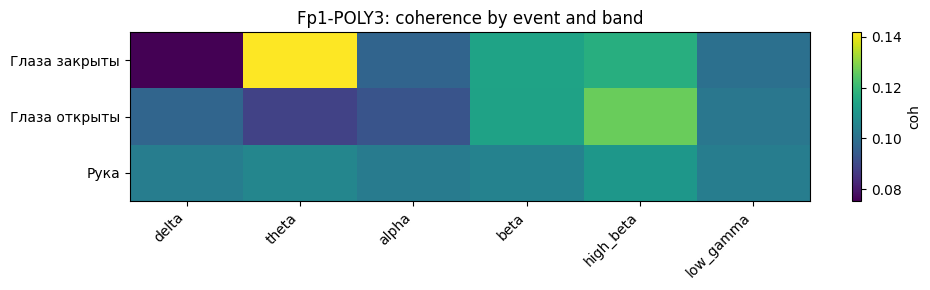

In [21]:
# Heatmap event × band для нескольких лучших пар.
for pair in top_project["pair"].drop_duplicates().head(5):
    plot_event_band_heatmap(
        project_results_df,
        pair=pair,
        metric="coh",
        title=f"{pair}: coherence by event and band",
    )

# 3. Сохранение результатов

In [22]:
OUTPUT_DIR = Path("analysis_results_mne_event_preprocessed")
OUTPUT_DIR.mkdir(exist_ok=True)

kaggle_results_df.to_csv(OUTPUT_DIR / "kaggle_mne_connectivity.csv", index=False, encoding="utf-8-sig")
project_results_df.to_csv(OUTPUT_DIR / "project_mne_eeg_poly_connectivity_by_event.csv", index=False, encoding="utf-8-sig")
project_pairs_df.to_csv(OUTPUT_DIR / "project_eeg_poly_pairs.csv", index=False, encoding="utf-8-sig")

print("Saved to", OUTPUT_DIR.resolve())

Saved to C:\Users\chuma\Documents\диплом\программа\analysis_results_mne_event_preprocessed
